# Imports

In [1]:
import math
import matplotlib.pyplot as plt
import numpy as np

from scipy.stats import norm

# Vanilla European Option Pricing

In [2]:
S = 100 # Stock Price
K = 100 # Strike Price
r = 0.05 # Risk-free rate (over a year)
sigma = 0.25 # Vol parameter (note that volatility = sigma * sqrt(# of periods in time horizon))
T = 0.2 # Time to expiry in years

In [3]:
d1 = 1 / (sigma * math.sqrt(T)) * (math.log(S / K) + (r + sigma**2 / 2) * T)
d2 = d1 - sigma * math.sqrt(T)

In [4]:
# Call price by BS
C = norm.cdf(d1) * S - norm.cdf(d2) * K * math.exp(-r * T)
print(f'Call price by BS: ${C:.3f}')

# Put price by put-call parity
D = 1 / (1 + r * T)
P = C - S + D * K
print(f'Put price by PCP: ${P:.3f}')


Call price by BS: $4.951
Put price by PCP: $3.961


In [5]:
# Put price by BS
P = norm.cdf(-d2) * K * math.exp(-r * T) - norm.cdf(-d1) * S
print(f'Put price by BS: ${P:.3f}')

# Call price by put-call parity
C = P + S - D * K
print(f'Call price by PCP: ${C:.3f}')

Put price by BS: $3.956
Call price by PCP: $4.946


### Dedicated Functions for Vanilla European Option Pricing Using Black-Scholes

In [6]:
def call_bs(S, K, r, sigma, T):
    '''Call price function (Black-Scholes)'''
    d1 = 1 / (sigma * math.sqrt(T)) * (math.log(S / K) + (r + sigma**2 / 2) * T)
    d2 = d1 - sigma * math.sqrt(T)
    return round(norm.cdf(d1) * S - norm.cdf(d2) * K * math.exp(-r * T), 3)

call_bs(S=110, K=100, r=0.085, sigma=0.8445, T=92/365)

24.156

In [7]:
def put_bs(S, K, r, sigma, T):
    '''Put price function (Black-Scholes)'''
    d1 = 1 / (sigma * math.sqrt(T)) * (math.log(S / K) + (r + sigma**2 / 2) * T)
    d2 = d1 - sigma * math.sqrt(T)
    return round(norm.cdf(-d2) * K * math.exp(-r * T) - norm.cdf(-d1) * S, 3)

put_bs(S=110, K=100, r=0.085, sigma=0.8445, T=92/365)

12.037

In [8]:
# Calculate call and put prices for many underlying prices
underlyings = np.arange(10, 201, 10)
call_prices_bs = np.array([call_bs(underlying, 100, 0.085, 0.8445, 92/365) for underlying in underlyings])
put_prices_bs = np.array([put_bs(underlying, 100, 0.085, 0.8445, 92/365) for underlying in underlyings])

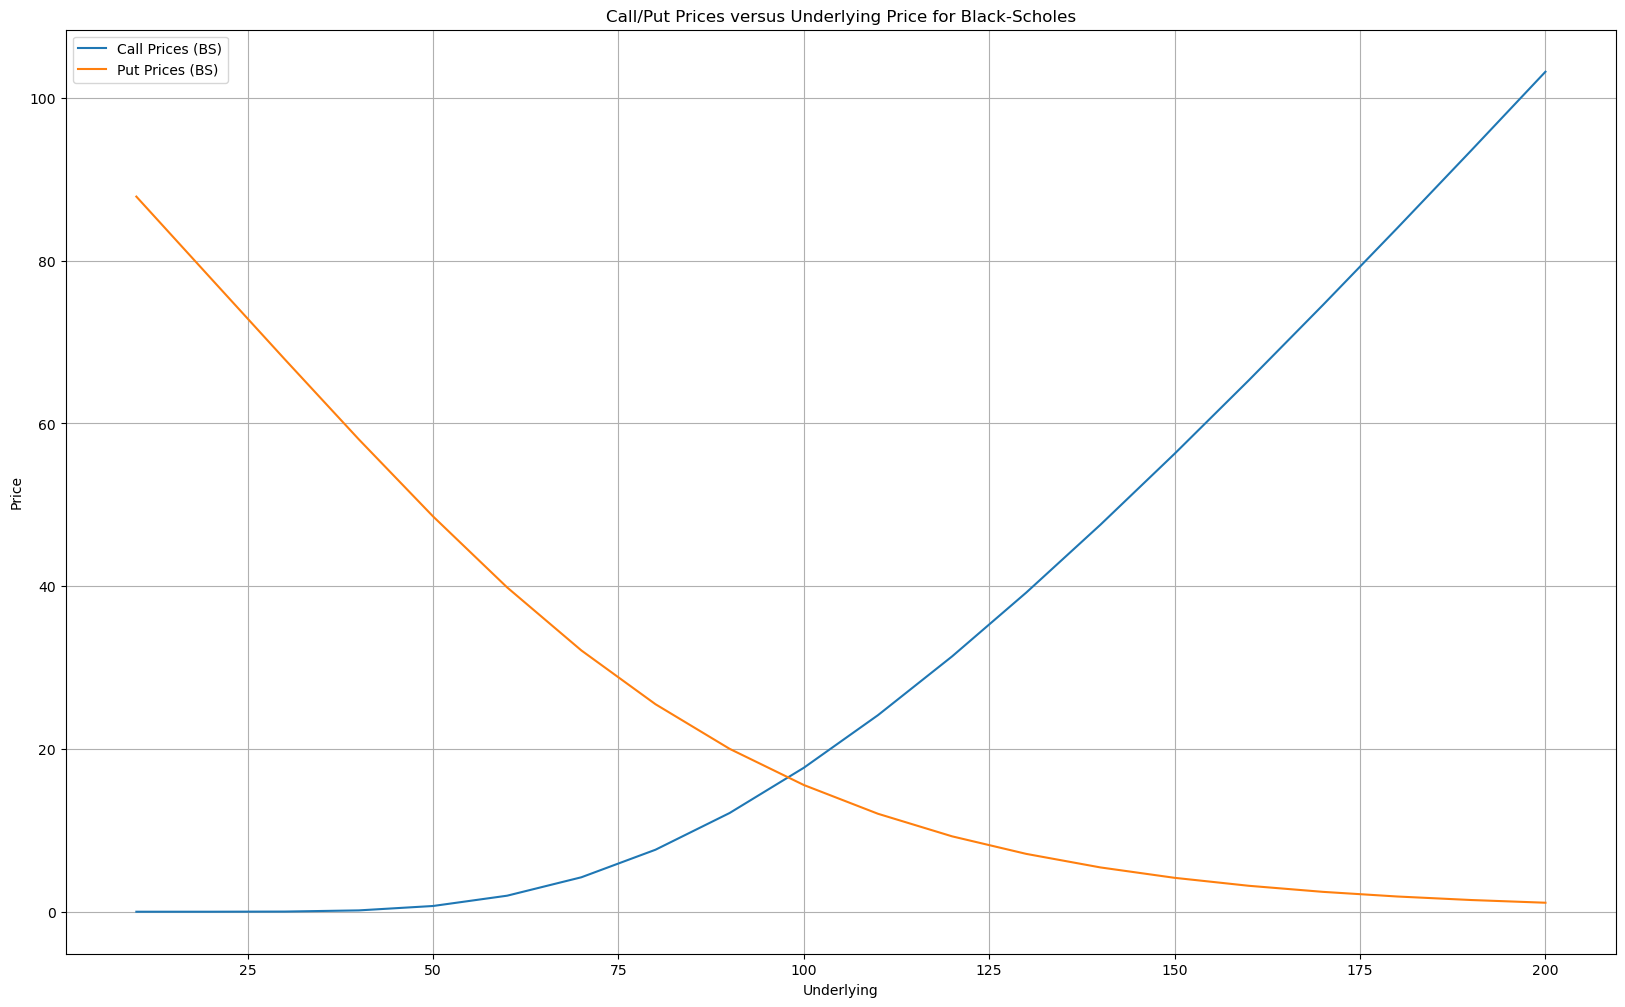

In [9]:
plt.figure(figsize=(20,12))
plt.plot(underlyings, call_prices_bs, label='Call Prices (BS)')
plt.plot(underlyings, put_prices_bs, label='Put Prices (BS)')

plt.xlabel('Underlying')
plt.ylabel('Price')
plt.legend()
plt.title('Call/Put Prices versus Underlying Price for Black-Scholes')
plt.grid()
plt.show()


### Closed-form Delta via Black-Scholes Derivatives

In [10]:
def call_delta_bs(S, K, r, sigma, T):
    '''Call delta function (Black-Scholes)'''
    d1 = 1 / (sigma * math.sqrt(T)) * (math.log(S / K) + (r + sigma**2 / 2) * T)
    return norm.cdf(d1)

def put_delta_bs(S, K, r, sigma, T):
    '''Put delta function (Black-Scholes)'''
    return call_delta_bs(S, K, r, sigma, T) - 1

In [11]:
# Calculate call and put deltas for many underlying prices
call_deltas_bs =  np.array([call_delta_bs(underlying, 100, 0.085, 0.8445, 92/365) for underlying in underlyings])
put_deltas_bs =  np.array([put_delta_bs(underlying, 100, 0.085, 0.8445, 92/365) for underlying in underlyings])

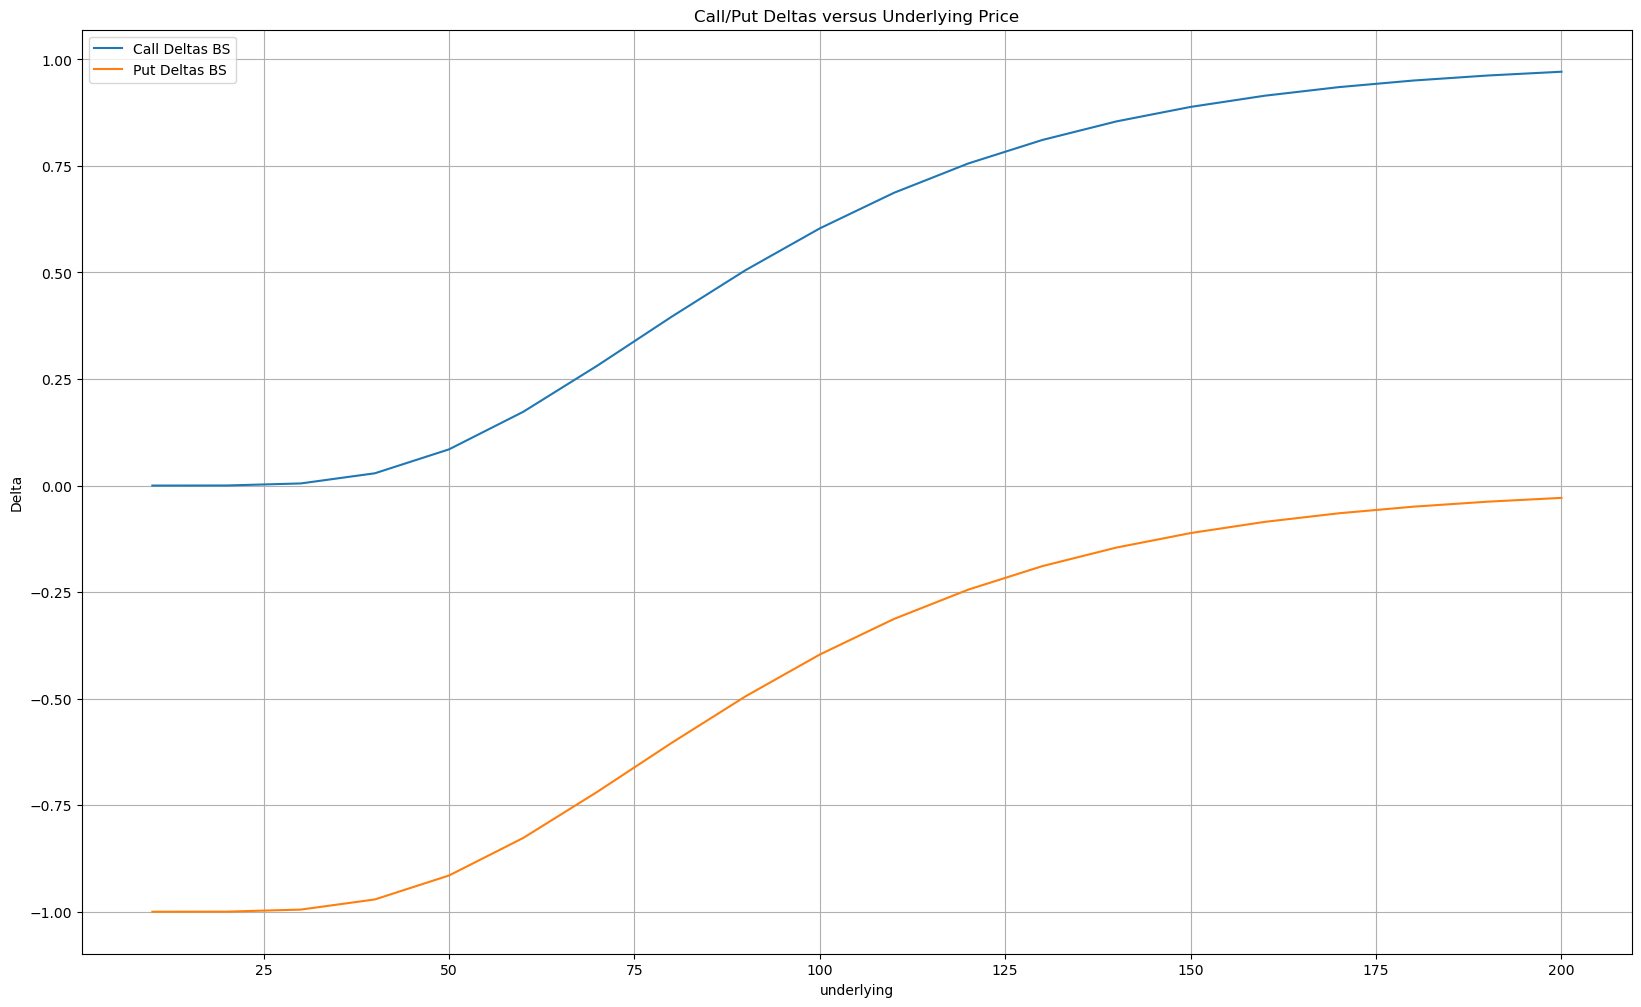

In [ ]:
plt.figure(figsize=(20,12))
plt.plot(underlyings, call_deltas_bs, label='Call Deltas BS')
plt.plot(underlyings, put_deltas_bs, label='Put Deltas BS')

plt.xlabel('underlying')
plt.ylabel('Delta')
plt.legend()
plt.title('Call/Put Deltas versus Underlying Price')
plt.grid()
plt.show()